In [14]:
# ============================================================
# 0. Imports
# ============================================================
import math
import random
from collections import deque

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

## 1. Configuration

In [15]:
# ============================================================
# 1. Configuration
# ============================================================
NODES_CSV = "output/processed_fishtree_nodes.csv"
EDGE_INDEX_NPY = "output/processed_fishtree_edge_index.npy"
EDGE_WEIGHT_NPY = "output/processed_fishtree_edge_weight.npy"

SEED = 42
EMB_DIM = 256
LR = 1e-4
WEIGHT_DECAY = 1e-5

NUM_STEPS = 50_000
BATCH_SIZE = 256

TRIPLET_MARGIN = 0.1
LAMBDA_PAIR = 1.0

ROOT_NODE = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Using device:", DEVICE)

Using device: cuda


## 2. Load the preprocessed tree

In [16]:
# ============================================================
# 2. Load data
# ============================================================
nodes_df = pd.read_csv(NODES_CSV)
edge_index = np.load(EDGE_INDEX_NPY)      # shape [2, E]
edge_weight = np.load(EDGE_WEIGHT_NPY)    # shape [E]

num_nodes = len(nodes_df)

print("num_nodes:", num_nodes)
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)

nodes_df.head()

num_nodes: 22919
edge_index shape: (2, 45836)
edge_weight shape: (45836,)


,node_id,node_name,is_leaf,species
0,0,internal_0,False,NaN
1,1,internal_1,False,NaN
2,2,internal_2,False,NaN
3,3,internal_3,False,NaN
4,4,internal_4,False,NaN


## 3. Build adjacency list
Your export already stores each undirected edge in both directions, so we can use it directly.

In [17]:
# ============================================================
# 3. Build adjacency list
# ============================================================
adj = [[] for _ in range(num_nodes)]

src = edge_index[0]
dst = edge_index[1]

for u, v, w in zip(src, dst, edge_weight):
    u = int(u)
    v = int(v)
    w = float(w)
    adj[u].append((v, w))

# Quick sanity check
degrees = np.array([len(nei) for nei in adj])
print("root node (degree 2):", np.argwhere(degrees == 2)[0])
print("min degree:", degrees.min())
print("max degree:", degrees.max())
print("mean degree:", degrees.mean())

root node (degree 2): [0]
min degree: 1
max degree: 3
mean degree: 1.999912736157773


## 4. Preprocess for fast exact tree-distance queries
We root the tree, then use:
- parent table for binary lifting
- weighted depth from root
- LCA-based exact path distance

In [18]:
# ============================================================
# 4. LCA preprocessing
# ============================================================
def preprocess_lca(adj, root=0):
    """
    Preprocess a weighted tree for fast distance queries.

    Returns
    -------
    parent : np.ndarray of shape [LOG, N]
        Binary lifting parent table.
    depth_edges : np.ndarray of shape [N]
        Number of edges from root.
    depth_weight : np.ndarray of shape [N]
        Weighted distance from root.
    """
    n = len(adj)
    LOG = math.ceil(math.log2(max(2, n))) + 1

    parent = np.full((LOG, n), -1, dtype=np.int64)
    depth_edges = np.full(n, -1, dtype=np.int64)
    depth_weight = np.zeros(n, dtype=np.float64)

    depth_edges[root] = 0
    q = deque([root])

    while q:
        u = q.popleft()
        for v, w in adj[u]:
            if depth_edges[v] != -1:
                continue
            depth_edges[v] = depth_edges[u] + 1
            depth_weight[v] = depth_weight[u] + w
            parent[0, v] = u
            q.append(v)

    for k in range(1, LOG):
        for v in range(n):
            p = parent[k - 1, v]
            parent[k, v] = -1 if p == -1 else parent[k - 1, p]

    return parent, depth_edges, depth_weight


def lca(u, v, parent, depth_edges):
    """
    Lowest common ancestor in O(log N).
    """
    if depth_edges[u] < depth_edges[v]:
        u, v = v, u

    LOG = parent.shape[0]

    # Lift u up to same depth as v
    diff = depth_edges[u] - depth_edges[v]
    for k in range(LOG):
        if diff & (1 << k):
            u = parent[k, u]

    if u == v:
        return u

    # Lift both together
    for k in reversed(range(LOG)):
        pu = parent[k, u]
        pv = parent[k, v]
        if pu != pv:
            u = pu
            v = pv

    return parent[0, u]


def tree_distance(u, v, parent, depth_edges, depth_weight):
    """
    Exact weighted tree distance in O(log N).
    """
    a = lca(u, v, parent, depth_edges)
    return depth_weight[u] + depth_weight[v] - 2.0 * depth_weight[a]

In [19]:
parent, depth_edges, depth_weight = preprocess_lca(adj, root=ROOT_NODE)

print("LCA table shape:", parent.shape)
print("Connected check:", np.all(depth_edges >= 0))
print("Max edge depth:", depth_edges.max())
print("Max weighted depth:", depth_weight.max())

LCA table shape: (16, 22919)
Connected check: True
Max edge depth: 65
Max weighted depth: 4.30323304515332


## 5. Identify leaves and internal nodes
Useful later for separate evaluation.

In [20]:
# ============================================================
# 5. Node type masks
# ============================================================
is_leaf = nodes_df["is_leaf"].astype(bool).to_numpy()
leaf_ids = np.where(is_leaf)[0]
internal_ids = np.where(~is_leaf)[0]

print("num leaves:", len(leaf_ids))
print("num internal:", len(internal_ids))

num leaves: 11460
num internal: 11459


## 6. Estimate a typical distance scale
We will use this for the pairwise target transform:

target similarity=e^(−d/τ)

In [21]:
# ============================================================
# 6. Estimate a distance scale tau
# ============================================================
def estimate_tau(num_samples=10000):
    dists = []
    for _ in range(num_samples):
        u = random.randrange(num_nodes)
        v = random.randrange(num_nodes)
        if u == v:
            continue
        d = tree_distance(u, v, parent, depth_edges, depth_weight)
        dists.append(d)
    return float(np.median(dists))

tau = estimate_tau()
print("Estimated tau:", tau)

Estimated tau: 2.2663445754442364


## 7. Simple embedding model
One trainable vector per node, L2-normalized before use.

In [22]:
# ============================================================
# 7. Model
# ============================================================
class NodeEmbeddingModel(nn.Module):
    def __init__(self, num_nodes, emb_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(num_nodes, emb_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, node_ids):
        z = self.embedding(node_ids)
        z = F.normalize(z, p=2, dim=-1)
        return z

    def get_all_embeddings(self):
        z = self.embedding.weight
        z = F.normalize(z, p=2, dim=-1)
        return z

## 8. Triplet sampler
This is the simplest readable version:

- sample anchor u
- sample two candidates
- whichever is closer becomes positive, the other negative
- require some distance separation

Later you can replace this with distance-band sampling.

In [23]:
# ============================================================
# 8. Sampler
# ============================================================
class TreeTripletSampler:
    def __init__(self, num_nodes, parent, depth_edges, depth_weight):
        self.num_nodes = num_nodes
        self.parent = parent
        self.depth_edges = depth_edges
        self.depth_weight = depth_weight

    def dist(self, u, v):
        return tree_distance(u, v, self.parent, self.depth_edges, self.depth_weight)

    def sample_triplet(self, max_tries=100):
        """
        Returns (u, v_close, w_far, d_uv, d_uw) or None.
        """
        u = random.randrange(self.num_nodes)

        for _ in range(max_tries):
            a = random.randrange(self.num_nodes)
            b = random.randrange(self.num_nodes)

            if a == u or b == u or a == b:
                continue

            da = self.dist(u, a)
            db = self.dist(u, b)

            if abs(da - db) < 1e-12:
                continue

            if da < db:
                v_close, w_far = a, b
                d_uv, d_uw = da, db
            else:
                v_close, w_far = b, a
                d_uv, d_uw = db, da

            # Require enough separation to make the triplet meaningful
            if d_uw > d_uv * 1.2:
                return u, v_close, w_far, d_uv, d_uw

        return None

    def sample_batch(self, batch_size):
        batch = []
        while len(batch) < batch_size:
            triplet = self.sample_triplet()
            if triplet is not None:
                batch.append(triplet)
        return batch

In [24]:
sampler = TreeTripletSampler(num_nodes, parent, depth_edges, depth_weight)

In [55]:
def sample_tree_distance_distribution(
    parent,
    depth_edges,
    depth_weight,
    num_nodes,
    num_samples=20000,
):
    dists = []
    for _ in range(num_samples):
        u = random.randrange(num_nodes)
        v = random.randrange(num_nodes)
        if u == v:
            continue
        d = tree_distance(u, v, parent, depth_edges, depth_weight)
        dists.append(d)
    return np.array(dists, dtype=np.float64)

In [59]:
dist_samples = sample_tree_distance_distribution(
    parent, depth_edges, depth_weight, num_nodes, num_samples=20000
)

for q in [1, 5, 10, 20, 30, 50, 70, 90, 95, 99]:
    print(f"p{q:2d} = {np.percentile(dist_samples, q):.4f}")

p 1 = 0.3506
p 5 = 0.7244
p10 = 0.9338
p20 = 1.2247
p30 = 1.5078
p50 = 2.2652
p70 = 2.9386
p90 = 3.3169
p95 = 3.5284
p99 = 4.0335


In [60]:
p10 = np.percentile(dist_samples, 10)
p40 = np.percentile(dist_samples, 40)
p80 = np.percentile(dist_samples, 80)

distance_bands = {
    "local": (0.0, p10),
    "mid":   (p10, p40),
    "far":   (p40, p80),
    "very_far": (p80, float("inf")),
}

print(distance_bands)

{'local': (0.0, np.float64(0.933815129334107)), 'mid': (np.float64(0.933815129334107), np.float64(1.8205740196164697)), 'far': (np.float64(1.8205740196164697), np.float64(3.096067907521501)), 'very_far': (np.float64(3.096067907521501), inf)}


In [61]:
class DistanceBandTripletSampler:
    def __init__(
        self,
        num_nodes,
        parent,
        depth_edges,
        depth_weight,
        bands,
    ):
        """
        bands: dict like
            {
                "local": (low, high),
                "mid": (low, high),
                "far": (low, high),
                "very_far": (low, high),
            }
        """
        self.num_nodes = num_nodes
        self.parent = parent
        self.depth_edges = depth_edges
        self.depth_weight = depth_weight
        self.bands = bands

    def dist(self, u, v):
        return tree_distance(u, v, self.parent, self.depth_edges, self.depth_weight)

    def in_band(self, d, band_name):
        low, high = self.bands[band_name]
        return (d > low) and (d <= high)

    def sample_node_in_band(self, anchor, band_name, max_tries=500):
        """
        Sample one node whose tree distance to anchor lies in the requested band.
        """
        for _ in range(max_tries):
            v = random.randrange(self.num_nodes)
            if v == anchor:
                continue
            d = self.dist(anchor, v)
            if self.in_band(d, band_name):
                return v, d
        return None

    def sample_triplet_from_bands(self, pos_band, neg_band, max_tries=100):
        """
        Returns (u, v_pos, w_neg, d_uv, d_uw) with d_uv < d_uw ideally.
        """
        for _ in range(max_tries):
            u = random.randrange(self.num_nodes)

            pos = self.sample_node_in_band(u, pos_band)
            neg = self.sample_node_in_band(u, neg_band)

            if pos is None or neg is None:
                continue

            v, d_uv = pos
            w, d_uw = neg

            if d_uv < d_uw:
                return u, v, w, d_uv, d_uw

        return None

    def sample_batch(
        self,
        batch_size,
        triplet_types=None,
    ):
        """
        triplet_types: list of (pos_band, neg_band), e.g.
            [("local", "mid"), ("local", "far"), ("mid", "far")]
        """
        if triplet_types is None:
            triplet_types = [("local", "mid"), ("local", "far"), ("mid", "far")]

        batch = []
        while len(batch) < batch_size:
            pos_band, neg_band = random.choice(triplet_types)
            t = self.sample_triplet_from_bands(pos_band, neg_band)
            if t is not None:
                batch.append(t)
        return batch

In [62]:
band_sampler = DistanceBandTripletSampler(
    num_nodes=num_nodes,
    parent=parent,
    depth_edges=depth_edges,
    depth_weight=depth_weight,
    bands=distance_bands,
)

## 9. Loss function

This combines:

- triplet ranking loss
- pairwise regression loss

In [ ]:
# ============================================================
# 9. Loss
# ============================================================
def cosine_sim(a, b):
    return (a * b).sum(dim=-1)


def pair_target_from_distance(d, tau):
    return torch.exp(-d / tau)


def compute_loss(
    model,
    batch_triplets,
    tau,
    margin=0.1,
    lambda_pair=0.2,
    device="cpu"
):
    u = torch.tensor([t[0] for t in batch_triplets], dtype=torch.long, device=device)
    v = torch.tensor([t[1] for t in batch_triplets], dtype=torch.long, device=device)
    w = torch.tensor([t[2] for t in batch_triplets], dtype=torch.long, device=device)

    d_uv = torch.tensor([t[3] for t in batch_triplets], dtype=torch.float32, device=device)
    d_uw = torch.tensor([t[4] for t in batch_triplets], dtype=torch.float32, device=device)

    z_u = model(u)
    z_v = model(v)
    z_w = model(w)

    s_uv = (z_u * z_v).sum(dim=-1)
    s_uw = (z_u * z_w).sum(dim=-1)

    triplet_loss = F.relu(margin - s_uv + s_uw).mean()

    target_uv = torch.exp(-d_uv / tau)
    target_uw = torch.exp(-d_uw / tau)

    # upweight close pairs
    weight_uv = 1.0 / (1.0 + d_uv)
    weight_uw = 1.0 / (1.0 + d_uw)

    pair_loss = (
        (weight_uv * (s_uv - target_uv) ** 2).mean()
        + (weight_uw * (s_uw - target_uw) ** 2).mean()
    )

    total_loss = triplet_loss + lambda_pair * pair_loss

    stats = {
        "loss": float(total_loss.item()),
        "triplet_loss": float(triplet_loss.item()),
        "pair_loss": float(pair_loss.item()),
        "mean_sim_close": float(s_uv.mean().item()),
        "mean_sim_far": float(s_uw.mean().item()),
        "mean_d_close": float(d_uv.mean().item()),
        "mean_d_far": float(d_uw.mean().item()),
    }
    return total_loss, stats

## 10. Train the model

In [ ]:
# ============================================================
# 10. Training
# ============================================================
model = NodeEmbeddingModel(num_nodes=num_nodes, emb_dim=EMB_DIM).to(DEVICE)
optimizer = Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

history = []

for step in range(NUM_STEPS):
    batch_triplets = band_sampler.sample_batch(
        BATCH_SIZE,
        triplet_types=[
            ("local", "mid"),
            ("local", "far"),
            ("mid", "far"),
        ]
    )

    optimizer.zero_grad()
    loss, stats = compute_loss(
        model=model,
        batch_triplets=batch_triplets,
        tau=tau,
        margin=TRIPLET_MARGIN,
        lambda_pair=LAMBDA_PAIR,
        device=DEVICE,
    )
    loss.backward()
    optimizer.step()

    history.append(stats)

    if step % 200 == 0:
        print(
            f"step={step:6d}  "
            f"loss={stats['loss']:.4f}  "
            f"triplet={stats['triplet_loss']:.4f}  "
            f"pair={stats['pair_loss']:.4f}  "
            f"sim_close={stats['mean_sim_close']:.4f}  "
            f"sim_far={stats['mean_sim_far']:.4f}"
        )

step=     0  loss=0.5439  triplet=0.1043  pair=0.4396  sim_close=0.0020  sim_far=-0.0000


step=   200  loss=0.5781  triplet=0.1049  pair=0.4732  sim_close=0.0011  sim_far=0.0010
step=   400  loss=0.5364  triplet=0.0974  pair=0.4390  sim_close=0.0086  sim_far=-0.0021
step=   600  loss=0.5214  triplet=0.1029  pair=0.4186  sim_close=0.0029  sim_far=-0.0012
step=   800  loss=0.5643  triplet=0.1011  pair=0.4632  sim_close=0.0005  sim_far=-0.0046
step=  1000  loss=0.5667  triplet=0.1019  pair=0.4648  sim_close=0.0004  sim_far=-0.0025
step=  1200  loss=0.5523  triplet=0.1067  pair=0.4456  sim_close=0.0047  sim_far=0.0048
step=  1400  loss=0.5464  triplet=0.0936  pair=0.4528  sim_close=0.0092  sim_far=-0.0045
step=  1600  loss=0.5376  triplet=0.0976  pair=0.4400  sim_close=0.0141  sim_far=0.0016
step=  1800  loss=0.5257  triplet=0.0908  pair=0.4350  sim_close=0.0201  sim_far=0.0004
step=  2000  loss=0.4813  triplet=0.0706  pair=0.4108  sim_close=0.0384  sim_far=-0.0072
step=  2200  loss=0.4408  triplet=0.0640  pair=0.3768  sim_close=0.0630  sim_far=0.0059
step=  2400  loss=0.4009  

## 11. Plot training curves

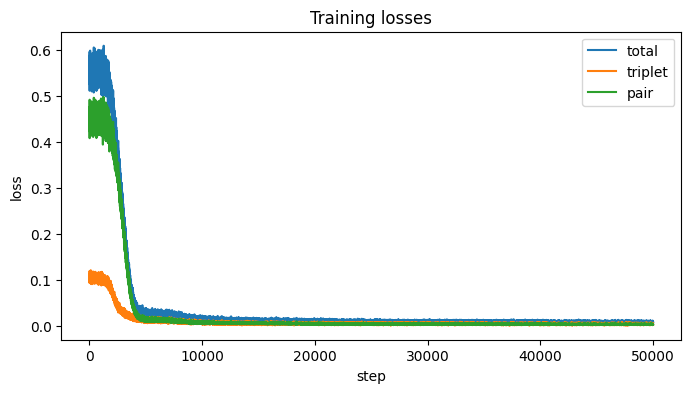

In [27]:
# ============================================================
# 11. Plot training curves
# ============================================================
import matplotlib.pyplot as plt

losses = [x["loss"] for x in history]
triplet_losses = [x["triplet_loss"] for x in history]
pair_losses = [x["pair_loss"] for x in history]

plt.figure(figsize=(8, 4))
plt.plot(losses, label="total")
plt.plot(triplet_losses, label="triplet")
plt.plot(pair_losses, label="pair")
plt.xlabel("step")
plt.ylabel("loss")
plt.legend()
plt.title("Training losses")
plt.show()

## 12. Evaluate correlation between embedding similarity and tree distance

We sample pairs and compare:

- true tree distance
- cosine similarity

We report:

- Spearman correlation between tree distance and -cosine_similarity
- Pearson correlation between tree distance and -cosine_similarity

In [28]:
# ============================================================
# 12. Evaluation helpers
# ============================================================
@torch.no_grad()
def evaluate_pair_correlation(
    model,
    parent,
    depth_edges,
    depth_weight,
    node_ids_a,
    node_ids_b,
    num_samples=10000,
    device="cpu"
):
    model.eval()

    dists = []
    neg_sims = []

    for _ in range(num_samples):
        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d = tree_distance(u, v, parent, depth_edges, depth_weight)

        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        sim = float((z[0] * z[1]).sum().item())

        dists.append(d)
        neg_sims.append(-sim)

    spearman = spearmanr(dists, neg_sims).correlation
    pearson = pearsonr(dists, neg_sims)[0]

    return {
        "num_pairs": len(dists),
        "spearman": float(spearman),
        "pearson": float(pearson),
    }

In [30]:
# ============================================================
# 12b. Evaluate by node type
# ============================================================
eval_leaf_leaf = evaluate_pair_correlation(
    model, parent, depth_edges, depth_weight,
    leaf_ids, leaf_ids,
    num_samples=10000,
    device=DEVICE
)

eval_leaf_internal = evaluate_pair_correlation(
    model, parent, depth_edges, depth_weight,
    leaf_ids, internal_ids,
    num_samples=10000,
    device=DEVICE
)

eval_internal_internal = evaluate_pair_correlation(
    model, parent, depth_edges, depth_weight,
    internal_ids, internal_ids,
    num_samples=10000,
    device=DEVICE
)

print("leaf-leaf:", eval_leaf_leaf)
print("leaf-internal:", eval_leaf_internal)
print("internal-internal:", eval_internal_internal)

leaf-leaf: {'num_pairs': 9999, 'spearman': 0.9649858837291909, 'pearson': 0.9668333472057195}
leaf-internal: {'num_pairs': 10000, 'spearman': 0.9654516671367911, 'pearson': 0.9669374662275261}
internal-internal: {'num_pairs': 10000, 'spearman': 0.9704475319492093, 'pearson': 0.9697911660546046}


## 13. Scatter plot of tree distance vs cosine similarity

In [31]:
# ============================================================
# 13. Scatter plot
# ============================================================
@torch.no_grad()
def sample_distance_similarity_points(
    model,
    parent,
    depth_edges,
    depth_weight,
    node_ids_a,
    node_ids_b,
    num_samples=3000,
    device="cpu"
):
    model.eval()

    dists = []
    sims = []

    for _ in range(num_samples):
        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d = tree_distance(u, v, parent, depth_edges, depth_weight)
        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        sim = float((z[0] * z[1]).sum().item())

        dists.append(d)
        sims.append(sim)

    return np.array(dists), np.array(sims)

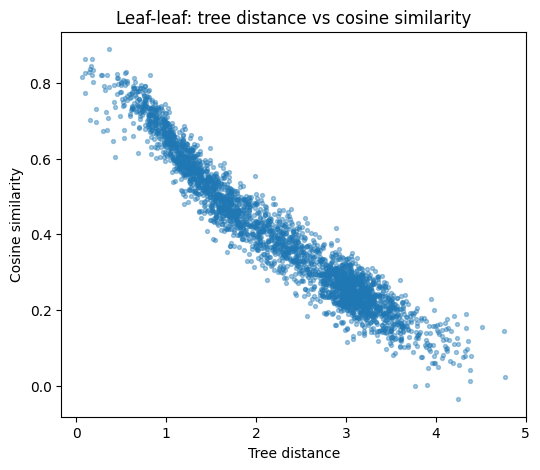

In [54]:
dists, sims = sample_distance_similarity_points(
    model, parent, depth_edges, depth_weight,
    leaf_ids, leaf_ids,
    num_samples=3000,
    device=DEVICE
)

plt.figure(figsize=(6, 5))
plt.scatter(dists, sims, s=8, alpha=0.4)
plt.xlabel("Tree distance")
plt.ylabel("Cosine similarity")
plt.title("Leaf-leaf: tree distance vs cosine similarity")
plt.show()

In [37]:
@torch.no_grad()
def evaluate_local_pair_correlation(
    model,
    parent,
    depth_edges,
    depth_weight,
    node_ids_a,
    node_ids_b,
    max_tree_dist,
    num_samples=10000,
    device="cpu",
    max_tries=200000,
):
    model.eval()

    dists = []
    neg_sims = []
    tries = 0

    while len(dists) < num_samples and tries < max_tries:
        tries += 1

        u = int(random.choice(node_ids_a))
        v = int(random.choice(node_ids_b))
        if u == v:
            continue

        d = tree_distance(u, v, parent, depth_edges, depth_weight)
        if d > max_tree_dist:
            continue

        z = model(torch.tensor([u, v], dtype=torch.long, device=device))
        sim = float((z[0] * z[1]).sum().item())

        dists.append(d)
        neg_sims.append(-sim)

    if len(dists) < 10:
        return {
            "num_pairs": len(dists),
            "spearman": np.nan,
            "pearson": np.nan,
        }

    return {
        "num_pairs": len(dists),
        "spearman": float(spearmanr(dists, neg_sims).correlation),
        "pearson": float(pearsonr(dists, neg_sims)[0]),
    }

In [43]:
local_eval = evaluate_local_pair_correlation(
    model,
    parent, depth_edges, depth_weight,
    leaf_ids, leaf_ids,
    max_tree_dist=0.5,
    num_samples=5000,
    device=DEVICE
)
print(local_eval)

{'num_pairs': 2595, 'spearman': 0.10590770674523073, 'pearson': 0.03088796335991346}


In [44]:
@torch.no_grad()
def cosine_similarity_to_candidates(model, anchor, candidates, device="cpu"):
    model.eval()

    nodes = torch.tensor([anchor] + candidates, dtype=torch.long, device=device)
    z = model(nodes)

    z_anchor = z[0]
    z_cands = z[1:]

    sims = torch.matmul(z_cands, z_anchor)  # cosine since normalized
    return sims.cpu().numpy()

def recall_at_k_single(
    model,
    anchor,
    candidates,
    k,
    parent,
    depth_edges,
    depth_weight,
    device="cpu"
):
    # --- true distances ---
    dists = np.array([
        tree_distance(anchor, v, parent, depth_edges, depth_weight)
        for v in candidates
    ])

    # smaller distance = closer
    true_order = np.argsort(dists)
    true_topk = set([candidates[i] for i in true_order[:k]])

    # --- embedding similarities ---
    sims = cosine_similarity_to_candidates(model, anchor, candidates, device)

    # larger similarity = closer
    pred_order = np.argsort(-sims)
    pred_topk = set([candidates[i] for i in pred_order[:k]])

    # --- recall ---
    intersection = len(true_topk & pred_topk)
    return intersection / k

@torch.no_grad()
def evaluate_recall_at_k(
    model,
    parent,
    depth_edges,
    depth_weight,
    node_ids,
    k=10,
    num_anchors=200,
    candidate_size=2000,
    device="cpu"
):
    model.eval()

    recalls = []

    node_ids = list(node_ids)

    for _ in range(num_anchors):
        anchor = random.choice(node_ids)

        # sample candidates (exclude anchor)
        candidates = random.sample(node_ids, min(candidate_size, len(node_ids)))
        if anchor in candidates:
            candidates.remove(anchor)

        if len(candidates) < k:
            continue

        r = recall_at_k_single(
            model,
            anchor,
            candidates,
            k,
            parent,
            depth_edges,
            depth_weight,
            device
        )
        recalls.append(r)

    return {
        "k": k,
        "num_anchors": len(recalls),
        "mean_recall": float(np.mean(recalls)),
        "std_recall": float(np.std(recalls)),
    }

In [48]:
# Leaf-only (most important biologically)
recall_leaf_5 = evaluate_recall_at_k(
    model,
    parent, depth_edges, depth_weight,
    leaf_ids,
    k=5,
    num_anchors=200,
    candidate_size=2000,
    device=DEVICE
)

recall_leaf_10 = evaluate_recall_at_k(
    model,
    parent, depth_edges, depth_weight,
    leaf_ids,
    k=10,
    num_anchors=200,
    candidate_size=2000,
    device=DEVICE
)

print("Leaf Recall@5:", recall_leaf_5)
print("Leaf Recall@10:", recall_leaf_10)

Leaf Recall@5: {'k': 5, 'num_anchors': 200, 'mean_recall': 0.138, 'std_recall': 0.17480274597385476}
Leaf Recall@10: {'k': 10, 'num_anchors': 200, 'mean_recall': 0.19, 'std_recall': 0.16822603841260722}
